# Closed-Loop Gain Recovery Test

Synthetic closed-loop demonstration of the `newnucal` calibration pipeline:

1. Build a HERA-like array and a random chromatic sky model
2. Simulate visibilities with `ForwardModel` at several times (Earth rotation) and frequencies
3. Apply known per-frequency gain degeneracies (amplitude, phase, phase gradient)
4. Recover gains with the sky held fixed — verifying the solution reproduces the data
5. Show joint sky + gain recovery starting from a perturbed sky

The key physics being tested: the DPSS spectral constraints on the sky/beam model, combined with Earth rotation that decorrelates sky pixels from beam pixels across time, provide enough information to reduce the residuals.  Note that the recovered gains need not match the injected ones exactly — there are residual degeneracies — but the calibrated model visibilities should match the data.

In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
from astropy.time import Time
from astropy.coordinates import EarthLocation
import astropy.units as u
import healpy

jax.config.update("jax_enable_x64", False)  # float32 throughout

from newnucal import HERAArray, BeamModel, BeamBasis, SkyBasis, SkyModel, ForwardModel, Calibrator, apply_gains, init_gain_params
from newnucal.utils import *
from newnucal.simulate import compute_rotation_matrices

%matplotlib inline
plt.rcParams.update({"figure.dpi": 110})

basis_vector_type was not defined, defaulting to azimuth and zenith_angle.
pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.


## 1. Array, frequency, and time setup

In [2]:

# --- Array ---
array = HERAArray.from_hex(hexnum=5, sep=14.6)
print(f"Antennas: {array.nants},  Baselines: {array.nbls}")

# --- Frequencies ---
#freqs = array.freq_array(50e6, 225e6)  # Hz
#nfreq = freqs.size
nfreq = 64
freqs = np.linspace(50e6, 225e6, nfreq, dtype=DTYPE_R_NPY)  # Hz
print(f"Freqs: {nfreq}, ({freqs[0]/1e6}--{freqs[-1]/1e6} MHz)")

# --- Times ---
hera_loc = EarthLocation(lat=-30.7215 * u.deg, lon=21.4283 * u.deg, height=1073.0 * u.m)
t0 = Time("2023-03-21T04:00:00", scale="utc")
nhrs = 3
ntime = nhrs * 4
dt = nhrs * 60  * u.min / (ntime + 1)
times = t0 + np.arange(ntime) * dt
print(f"Times: {ntime},  span: {(times[-1] - times[0]).to(u.min):.1f}")

# --- Rotation matrices ---
rot_matrices = compute_rotation_matrices(times, hera_loc)
print(f"rot_matrices shape: {rot_matrices.shape}")


Antennas: 56,  Baselines: 236
Freqs: 64, (50.0--225.0 MHz)
Times: 12,  span: 152.3 min
rot_matrices shape: (12, 3, 3)


## 2. Beam and sky model

In [3]:
sky_nside = 32
beam_nside = 16

# Beam: Airy disk (HERA dish diameter 14.6 m), DPSS eta_max = 20 ns
#beam_basis = BeamBasis.from_dpss(freqs, eta_max=20e-9)
beam_basis = BeamBasis.from_file('beam_basis_airy.npz', new_freqs=freqs)
beam_model = BeamModel(nside=beam_nside, freqs=freqs, basis=beam_basis)
print(f"Beam Nmodes: {beam_model.nmodes}")

# Sky: random power-law HEALPix map
npix_sky = healpy.nside2npix(sky_nside)
rng = np.random.default_rng(42)

# Build a smooth chromatic sky: per-pixel spectral index drawn from N(-0.7, 0.1)
ref_freq = 150e6
spectral_indices = rng.normal(-0.7, 0.1, npix_sky).astype(DTYPE_R_NPY)
ref_flux = rng.exponential(scale=1.0, size=npix_sky).astype(DTYPE_R_NPY)
# flux_true[npix, nfreq]
flux_true = ref_flux[:, None] * (freqs[None, :] / ref_freq) ** spectral_indices[:, None]

# Project onto sky DPSS basis
#sky_basis = SkyBasis.from_dpss(freqs, eta_max=40e-9)
sky_basis = SkyBasis.from_file('sky_basis_gsm_gleam.npz', new_freqs=freqs)
sky_coeffs_true = jnp.array(sky_basis.project(flux_true), dtype=DTYPE_R_JAX)
sky_model  = SkyModel(nside=sky_nside, freqs=freqs, basis=sky_basis)
print(f"Sky Nmodes: {sky_model.nmodes}")

Beam Nmodes: 18
Sky Nmodes: 6


## 3. Simulate true visibilities and apply known gain perturbations

In [4]:
fwd = ForwardModel(array, sky_model, beam_model, freqs, eps=1e-5)

print("Simulating true visibilities (this compiles the JIT on first run)...")
vis_true = fwd.simulate(sky_coeffs_true, jnp.array(rot_matrices))
print(f"vis_true shape: {vis_true.shape},  dtype: {vis_true.dtype}")
print(f"Mean |vis|: {float(jnp.abs(vis_true).mean()):.4f}")

Simulating true visibilities (this compiles the JIT on first run)...
vis_true shape: (12, 64, 236),  dtype: complex64
Mean |vis|: 7.1868


In [5]:
# --- True gain perturbations (per time and frequency) ---
# Gains vary smoothly in both time and frequency, mimicking slow ionospheric drift.

t_norm = np.linspace(0, 1, ntime)[:, None]   # (ntime, 1)  — normalised time axis
f_norm = np.linspace(0, 1, nfreq)[None, :]   # (1, nfreq) — normalised frequency axis

# log_amp: ~5% amplitude variation across band, with ~2% slow drift in time
true_log_amp = (
    0.05 * np.cos(2 * np.pi * f_norm)
    + 0.02 * np.sin(2 * np.pi * t_norm)
).astype(np.float32)  # (ntime, nfreq)

# phase: smooth variation in frequency, slow drift in time
true_phase = (
    0.15 * np.sin(2 * np.pi * f_norm)
    + 0.05 * np.cos(2 * np.pi * t_norm)
).astype(DTYPE_R_NPY)  # (ntime, nfreq)

# phi: small phase gradients with independent time and frequency variation
true_phi = np.zeros((ntime, 2, nfreq), dtype=DTYPE_R_NPY)
true_phi[:, 0, :] = (                               # East
    1e-4 * np.cos(2 * np.pi * f_norm)
    + 3e-5 * np.sin(2 * np.pi * t_norm)
)
true_phi[:, 1, :] = (                               # North
    5e-5 * np.sin(2 * np.pi * f_norm)
    + 2e-5 * np.cos(2 * np.pi * t_norm)
)

true_log_amp_j = jnp.array(true_log_amp)
true_phase_j   = jnp.array(true_phase)
true_phi_j     = jnp.array(true_phi)

vis_data = apply_gains(vis_true, true_log_amp_j, true_phase_j, true_phi_j,
                       jnp.array(array.bls, dtype=DTYPE_R_JAX))

# Inject narrowband RFI
rfi_ch = 20
vis_data_rfi = np.array(vis_data, copy=True)
vis_data_rfi[:, rfi_ch, :] += 10.0 * (1.0 + 0.3j)
vis_data_rfi = jnp.array(vis_data_rfi, dtype=DTYPE_C_JAX)

print(f"vis_data shape: {vis_data.shape}")

vis_data shape: (12, 64, 236)


In [6]:
cal = Calibrator(
    array=array,
    sky_model=sky_model,
    beam_model=beam_model,
    freqs=freqs,
    rot_matrices=rot_matrices,
    data=vis_data_rfi,
    #data=vis_data,
    eps=1e-5,
)

  (7265 above-horizon pixels retained after cut)


In [7]:
beam_mask = cal.build_beam_mask_altitude(60)
#beam_mask = cal.build_beam_mask_altitude(0)
sky_mask = cal.build_sky_mask_from_beam_pixels(beam_mask)
cal.apply_sky_mask(sky_mask)
cal.apply_beam_mask(beam_mask)

  Pixel mask: 1566 pixels retained, 10722 removed.
  Beam mask: 220 pixels retained, 2852 removed.


Ignoring specified arguments in this call because figure with num: 1 already exists


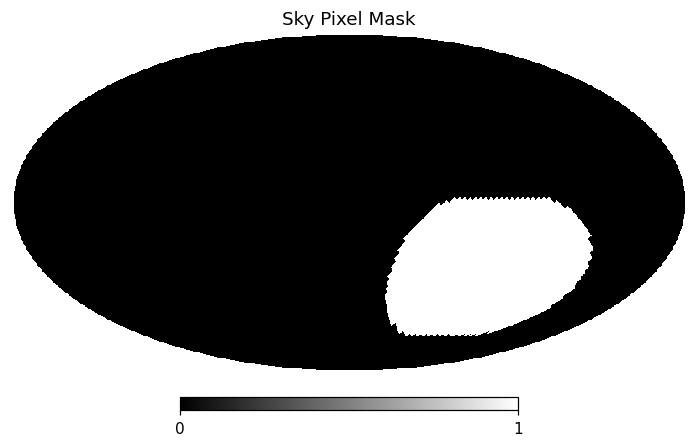

In [8]:
fig = plt.figure()
#healpy.mollview(bm_wgts, fig=fig, sub=(2, 1, 1), title="Sky Beam Weighting", cmap="plasma")
#healpy.mollview(sky_mask,fig=fig, sub=(2, 1, 2), title="Sky Pixel Mask", cmap="gray")
healpy.mollview(sky_mask,fig=fig, title="Sky Pixel Mask", cmap="gray")

Ignoring specified arguments in this call because figure with num: 1 already exists


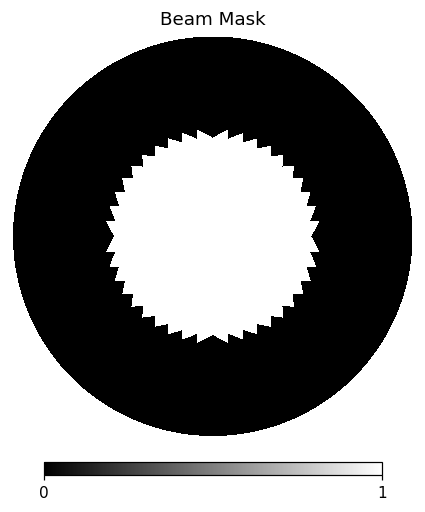

In [9]:
fig = plt.figure()
healpy.orthview(beam_mask, rot=(0, 90, 0), half_sky=True, fig=fig, title="Beam Mask", cmap="gray")

## 5. Data reproduction: baseline spectra and loss

In [10]:
freq_mhz = freqs / 1e6
t_show = 0
bls_j    = jnp.array(array.bls, dtype=DTYPE_R_JAX)
beam_j   = jnp.array(beam_model.coeffs, dtype=DTYPE_R_JAX)
bl_indices = [0, array.nbls // 4, array.nbls // 2, array.nbls - 1]

## 6. Joint sky + gain + beam recovery (perturbed start)

Start the sky from a perturbed version of the truth (30% Gaussian noise on DPSS coefficients) and the beam from a perturbed version (10% noise). Jointly optimize sky, gains, and beam using `fit_alternating_dirty` with `solve_every` scheduling. This tests whether Earth rotation + DPSS spectral constraints are sufficient to disentangle all three components.

In [11]:
rng2 = np.random.default_rng(99)
sky_coeffs_perturbed = sky_coeffs_true + 0.30 * jnp.array(
    rng2.standard_normal(sky_coeffs_true.shape).astype(DTYPE_R_NPY)
) * float(jnp.abs(sky_coeffs_true).mean())

# Perturb the beam coefficients by 10% Gaussian noise
beam_coeffs_true = jnp.array(beam_model.coeffs, dtype=DTYPE_R_JAX)
rng3 = np.random.default_rng(77)
beam_coeffs_perturbed = beam_coeffs_true + 0.30 * jnp.array(
    rng3.standard_normal(beam_coeffs_true.shape).astype(DTYPE_R_NPY)
) * float(jnp.abs(beam_coeffs_true).mean())

prms0 = {
    "sky_coeffs":  sky_coeffs_perturbed,
    "beam_coeffs": beam_coeffs_perturbed,
    "log_ch_weights": jnp.zeros(nfreq, dtype=DTYPE_R_JAX),
    **init_gain_params(ntime, nfreq),
}

In [12]:
loss_init = cal.calc_loss(prms0)
vis_init  = cal.simulate(prms0)

In [13]:
prms = prms0.copy()

In [ ]:

# Fit with RFI weighting: update weights every 4 iterations
prms, loss = cal.fit_joint_sky_beam_dirty(
    prms,
    n_iter=30,
    #joint_initial_step=[0.3, 1.0, 3.0],
    sky_beam_reg=1e-3,
    #sky_beam_reg=1e-5,
    solve_every={'gains': 8, 'rfi': 3},
    rfi_smooth_width_chans=7,         # local baseline filter                            
    rfi_threshold_ratio=3.0,           # outlier threshold
    rfi_gamma=0.75,                    # exponential rate                                 
    rfi_min_weight=0.05,                                  
    rfi_alpha_down=0.20,               # slow downweight                                  
    rfi_alpha_up=0.75,                 # fast recovery                                    
    rfi_max_drop=0.20,
    #rfi_regularization=20.0,               # λ for quadratic penalty
    #rfi_regularization_power=2.0,         # Use quadratic (closed-form solution)
    #initial_flags=rfi_flgs_init,
    #initial_channel_weights=rfi_wgts_init,
    max_rfi_updates=None,  # Allow updates throughout fit
    joint_anderson_history=2,
    verbose=True,
)
print(f"Loss: {loss:.4e}")

    [gains 000]: loss=5.8605e+05  eff=3.94e-01 frac_Δloss/s
  step 0000 [gains      ]: chi2=5.8605e+05  eff[joint= N/A   gains=3.94e-01]  t=-0.0s
    [joint    000]: loss=5.2820e+05  eff=3.02e-02 frac_Δloss/s  step_gain=1.00
  step 0001 [joint      ]: chi2=5.2820e+05  eff[joint=3.02e-02 gains=3.94e-01]  t=3.3s
    [joint    001]: loss=4.8705e+05  eff=2.78e-02 frac_Δloss/s  step_gain=1.00
  step 0002 [joint      ]: chi2=4.8705e+05  eff[joint=2.92e-02 gains=3.94e-01]  t=6.1s
    [joint AA 002]: loss=4.2163e+05  eff=5.36e-02 frac_Δloss/s  step_gain=1.00  [AA improved: cand=4.2163e+05 vs plain=4.5596e+05]
    [rfi 000]: frac(w<0.5)=0.000
  step 0003 [joint      ]: chi2=4.2163e+05  eff[joint=3.90e-02 gains=3.94e-01]  t=9.4s
    [joint AA 003]: loss=3.3102e+05  eff=7.88e-02 frac_Δloss/s  step_gain=1.00  [AA improved: cand=3.3102e+05 vs plain=3.4629e+05]
  step 0004 [joint      ]: chi2=3.3102e+05  eff[joint=5.49e-02 gains=3.94e-01]  t=12.1s
    [joint AA 004]: loss=3.0498e+05  eff=3.17e-02 fr

In [ ]:
vis_fit  = cal.simulate(prms)

print(f"  Improvement:                   {loss_init / loss:.2f}x")

resid_init = jnp.abs(vis_data_rfi - vis_init)
resid_rfi_fit  = jnp.abs(vis_data_rfi - vis_fit)

fig, axes = plt.subplots(len(bl_indices), 2, figsize=(13, 2.8 * len(bl_indices)), sharex=True)
fig.suptitle(
    f"Fit Comparison on RFI-Contaminated Data (channel {rfi_ch})"
    f"  —  Baseline loss {loss_init:.2e} → RFI-weighted loss {loss:.2e}",
    fontsize=11,
)
for row, bi in enumerate(bl_indices):
    bl_len = float(jnp.linalg.norm(bls_j[bi, :2]))

    ax = axes[row, 0]
    ax.semilogy(freq_mhz, jnp.abs(vis_data_rfi)[t_show, :, bi],         "k-",  lw=1.5, label="Contaminated data")
    ax.semilogy(freq_mhz, resid_init[t_show, :, bi], 
                "b--", lw=1.2, label="Baseline residual", alpha=0.7)
    ax.semilogy(freq_mhz, resid_rfi_fit[t_show, :, bi],  
                "r--", lw=1.5, label="RFI-weighted residual")
    ax.axvline(freqs[rfi_ch]/1e6, color='orange', linestyle=':', lw=2, label=f"RFI ch{rfi_ch}")
    ax.set_ylabel(f"bl {bi} ({bl_len:.0f}m)\n|V|")
    if row == 0: ax.legend(fontsize=8, loc='upper right')
    if row == len(bl_indices) - 1: ax.set_xlabel("Frequency (MHz)")

    ax = axes[row, 1]
    ax.plot(freq_mhz, jnp.angle(vis_data)[t_show, :, bi],         "k-",  lw=1.5, label="Contaminated data")
    ax.plot(freq_mhz, jnp.angle(vis_data_rfi)[t_show, :, bi], 
            "b--", lw=1.2, label="Baseline model", alpha=0.7)
    ax.plot(freq_mhz, jnp.angle(vis_fit)[t_show, :, bi],  
            "r--", lw=1.5, label="RFI-weighted model")
    ax.axvline(freqs[rfi_ch]/1e6, color='orange', linestyle=':', lw=2, label=f"RFI ch{rfi_ch}")
    ax.set_ylabel(f"bl {bi} ({bl_len:.0f}m)\narg(V) (rad)")
    if row == 0: ax.legend(fontsize=8, loc='upper right')
    if row == len(bl_indices) - 1: ax.set_xlabel("Frequency (MHz)")

plt.tight_layout(); plt.show()

# Show per-channel residual power comparison
print("\nPer-channel RMS residual (averaged over time and baseline):")
resid_init_f = resid_init.mean(axis=(0, 2))  # Average over time and baseline
resid_rfi_fit_f  = resid_rfi_fit.mean(axis=(0, 2))
resid_data_f     = jnp.abs(vis_data_rfi).mean(axis=(0, 2))

fig, ax = plt.subplots(figsize=(12, 4))
ax.semilogy(freq_mhz, resid_data_f,     "k-",  lw=2, label="Data (contaminated)")
ax.semilogy(freq_mhz, resid_init_f, "b--", lw=1.5, label="Initial residual", alpha=0.7)
ax.semilogy(freq_mhz, resid_rfi_fit_f,  "r--", lw=1.5, label="RFI-weighted residual")
ax.axvline(freqs[rfi_ch]/1e6, color='orange', linestyle=':', lw=2, label=f"RFI injected (ch{rfi_ch})")
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("RMS Residual")
ax.set_title("Per-channel RMS residual comparison: baseline vs RFI-weighted fit")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

In [ ]:
from newnucal.rfi import channel_chi2_statistic
# Compute chi2 statistics on residuals from both fits
print("RFI CHANNEL WEIGHT DIAGNOSTICS")
print("="*70)
# Compute chi2 statistics on init residuals (without RFI weighting)
resid_init_raw = vis_data_rfi - vis_init
inv_noise_var = np.ones((nfreq,), dtype=np.float32)  # Uniform noise assumption
chi2_init = channel_chi2_statistic(resid_init_raw, inv_noise_var=inv_noise_var)
chi2_f_init = jnp.median(chi2_init, axis=0)  # Median over time
# Compare with RFI-weighted fit residuals
resid_rfi_raw = vis_data_rfi - vis_fit
chi2_rfi = channel_chi2_statistic(resid_rfi_raw, inv_noise_var=inv_noise_var)
chi2_f_rfi = jnp.median(chi2_rfi, axis=0)  # Median over time
print(f"Channel {rfi_ch} ({freqs[rfi_ch]/1e6:.1f} MHz) — RFI injection channel:")
print(f"  init chi2:            {float(chi2_f_init[rfi_ch]):.4f}")
print(f"  RFI-weighted chi2:    {float(chi2_f_rfi[rfi_ch]):.4f}")
# Get fitted channel weights from the calibrator (updated during RFI iterations)
fitted_weights = np.asarray(cal.channel_weights)
# Average across time for display
fitted_weights_f = np.mean(fitted_weights, axis=0)
print(f"Fitted channel weights (from RFI optimization):")
print(f"  RFI channel weight:   {fitted_weights_f[rfi_ch]:.4f}")
print(f"  Neighbor channels:    {fitted_weights_f[rfi_ch-1]:.4f}, {fitted_weights_f[rfi_ch+1]:.4f}")
# Plot: chi2 and fitted weights
fig, axes = plt.subplots(2, 1, figsize=(13, 6))
# Top panel: chi2 statistics
ax = axes[0]
ax.semilogy(freq_mhz, chi2_f_init,         "b-",  lw=1.5, label="init (no RFI fit)", alpha=0.5)
ax.semilogy(freq_mhz, chi2_f_rfi,         "r-",  lw=1.5, label="RFI-weighted fit", alpha=0.5)
ax.axvline(freqs[rfi_ch]/1e6, color='orange', linestyle=':', lw=2.5, label=f"RFI channel {rfi_ch}")
ax.axhline(1.0, color='gray', linestyle='--', lw=1, alpha=0.5)
ax.set_ylabel("Chi² statistic (per channel)")
ax.set_title("Per-channel chi² residual power: init vs RFI-weighted fit")
ax.legend(fontsize=9, loc='upper left')
ax.grid(True, alpha=0.3)
# Bottom panel: fitted soft weights from RFI optimization
ax = axes[1]
ax.plot(freq_mhz, fitted_weights_f, "g-", lw=2.5, label="Fitted weights (RFI opt)", marker="o", markersize=4)
ax.axvline(freqs[rfi_ch]/1e6, color='orange', linestyle=':', lw=2.5, label=f"RFI channel {rfi_ch}")
ax.axhline(1.0, color='gray', linestyle='--', lw=1, alpha=0.5)
ax.axhline(0.01, color='gray', linestyle=':', lw=1, alpha=0.5)
ax.set_xlabel("Frequency (MHz)")
ax.set_ylabel("Soft weight")
ax.set_ylim([0, 1.1])
ax.set_title("RFI-optimized channel weights: contaminated channel heavily downweighted")
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## 7. Recovered sky map

In [ ]:
# Reconstruct sky flux from DPSS coefficients at a reference frequency
ifreq_ref = np.argmin(np.abs(freqs - ref_freq))

sky_true_map = np.array(flux_true[:, ifreq_ref])
# Deproject: unsolved pixels keep perturbed values; mask zeroes them out
sky_rec_full = np.array(sky_basis.deproject(np.asarray(prms["sky_coeffs"])))[:, ifreq_ref]
sky_rec_map  = cal.pixel_mask * sky_rec_full
sky_diff_map = cal.pixel_mask * (sky_rec_full - sky_true_map)

vmax = np.percentile(sky_true_map[sky_mask], 99)
vmin = 0.0
diff_scale = np.percentile(np.abs(sky_diff_map[sky_mask]), 99)

fig = plt.figure(figsize=(12, 9))
healpy.mollview(sky_true_map, fig=fig, sub=(3, 1, 1),
                title=f"True sky  ({ref_freq/1e6:.0f} MHz)", min=vmin, max=vmax,
                unit="Jy/pix", cmap="inferno")
healpy.mollview(sky_rec_map,  fig=fig, sub=(3, 1, 2),
                title="Recovered sky  (joint fit, solved pixels only)", min=vmin, max=vmax,
                unit="Jy/pix", cmap="inferno")
healpy.mollview(sky_diff_map, fig=fig, sub=(3, 1, 3),
                title="Residual (recovered − true, solved pixels)", min=-diff_scale, max=diff_scale,
                unit="Jy/pix", cmap="RdBu_r")
plt.show()

## 8. Recovered beam map and spectra

In [ ]:
# Reconstruct beam spectra from DPSS coefficients: (npix_beam, nfreq)
beam_spec_true     = np.array(beam_basis.deproject(np.asarray(beam_coeffs_true)))
beam_spec_perturb  = np.array(beam_basis.deproject(np.asarray(beam_coeffs_perturbed)))
beam_spec_rec      = np.array(beam_basis.deproject(np.asarray(prms["beam_coeffs"])))

rms_before = float(np.sqrt(np.mean((beam_spec_perturb - beam_spec_true) ** 2)))
rms_after  = float(np.sqrt(np.mean((beam_spec_rec     - beam_spec_true) ** 2)))
rms_signal = float(np.sqrt(np.mean(beam_spec_true ** 2)))
print(f"Beam RMS error — before: {rms_before:.4e}  after: {rms_after:.4e}  "
      f"(signal: {rms_signal:.4e})")
print(f"  relative: {rms_before/rms_signal:.3f} → {rms_after/rms_signal:.3f}")

# --- HEALPix maps at reference frequency ---
ifreq_ref = np.argmin(np.abs(freqs - ref_freq))

vmax_b = np.percentile(beam_spec_true[:, ifreq_ref], 99)

fig = plt.figure(figsize=(12, 10))
healpy.orthview(beam_spec_true[:, ifreq_ref], rot=(0, 90, 0), half_sky=True,
                fig=fig, sub=(3, 1, 1),
                title=f"True beam  ({ref_freq/1e6:.0f} MHz)",
                min=0, max=vmax_b, cmap="inferno")
healpy.orthview(beam_spec_rec[:, ifreq_ref], rot=(0, 90, 0), half_sky=True,
                fig=fig, sub=(3, 1, 2),
                title="Recovered beam  (joint fit)",
                min=0, max=vmax_b, cmap="inferno")
diff_b = beam_spec_rec[:, ifreq_ref] - beam_spec_true[:, ifreq_ref]
dscale = np.percentile(np.abs(diff_b), 99)
healpy.orthview(diff_b, rot=(0, 90, 0), half_sky=True,
                fig=fig, sub=(3, 1, 3),
                title="Residual (recovered − true)",
                min=-dscale, max=dscale, cmap="RdBu_r")
plt.show()

# --- Spectra at the peak-beam pixel and a few others ---
peak_px = int(np.argmax(beam_spec_true[:, ifreq_ref]))
sample_pxs = [peak_px,
               int(np.argsort(beam_spec_true[:, ifreq_ref])[-beam_spec_true.shape[0]//4]),
               int(np.argsort(beam_spec_true[:, ifreq_ref])[-beam_spec_true.shape[0]//2])]

fig, axes = plt.subplots(1, len(sample_pxs), figsize=(13, 4), sharey=False)
fig.suptitle("Beam spectra at selected pixels: true vs. perturbed vs. recovered", fontsize=11)
for ax, px in zip(axes, sample_pxs):
    ax.plot(freq_mhz, beam_spec_true[px],    "k-",  lw=2,   label="True")
    ax.plot(freq_mhz, beam_spec_perturb[px], "b--", lw=1.2, label="Perturbed", alpha=0.7)
    ax.plot(freq_mhz, beam_spec_rec[px],     "r--", lw=1.5, label="Recovered")
    ax.set_title(f"pixel {px}")
    ax.set_xlabel("Frequency (MHz)")
    ax.set_ylabel("Beam amplitude")
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()